In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image

In [27]:

#Implement the number of vertical and horizontal corners

nb_vertical = 9
nb_horizontal = 6


# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((nb_horizontal*nb_vertical,3), np.float32)
objp[:,:2] = np.mgrid[0:nb_vertical,0:nb_horizontal].T.reshape(-1,2)

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints_left= [] # 2d points in image plane.
imgpoints_right=[] #2d points in image plane


images_right = sorted(glob.glob('rsimages/right-*.png'))
images_left=sorted(glob.glob('rsimages/left-*.png'))


assert images_right and images_left

for fname_left,fname_right in zip(images_left,images_right):
    img_left = cv2.imread(fname_left)
    gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)

    img_right=cv2.imread(fname_right)
    gray_right=cv2.cvtColor(img_right,cv2.COLOR_BGR2GRAY)

    
    #Implement findChessboardCorners here
    ret_left, corners_left = cv2.findChessboardCorners(gray_left,(nb_vertical, nb_horizontal))
    ret_right,corners_right=cv2.findChessboardCorners(gray_right,(nb_vertical,nb_horizontal))


    # If found, add object points, image points (after refining them)
    if ret_left == True and ret_right==True:
        objpoints.append(objp)

        imgpoints_left.append(corners_left)
        imgpoints_right.append(corners_right)

        # Draw and display the corners
        img_left = cv2.drawChessboardCorners(img_left, (nb_vertical,nb_horizontal), corners_left,ret_left)
        cv2.imshow('img',img_left)
        cv2.waitKey(100)

        img_right=cv2.drawChessboardCorners(img_right,(nb_vertical,nb_horizontal), corners_right, ret_right)
        cv2.imshow('img',img_right)
        cv2.waitKey(100)

cv2.destroyAllWindows()


In [22]:
ret_left, mtx_left, dist_left, rvecs_left, tvecs_left = cv2.calibrateCamera(objpoints, imgpoints_left, gray_left.shape[::-1], None, None)
img_left = cv2.imread('rsimages/left-0000.png')
h,  w = img_left.shape[:2]
newcameramtx_left, roi_left = cv2.getOptimalNewCameraMatrix(mtx_left,dist_left,(w,h),1,(w,h))

ret_right, mtx_right, dist_right,rvecs_right,tvecs_right=cv2.calibrateCamera(objpoints, imgpoints_right,gray_right.shape[::-1],None, None)
img_right=cv2.imread('rsimages/right-0000.png')
h, w=img_right.shape[:2]
newcameramtx_right, roi_right=cv2.getOptimalNewCameraMatrix(mtx_right,dist_right,(w,h),1,(w,h))


Text(0.5, 1.0, 'Undistorted image')

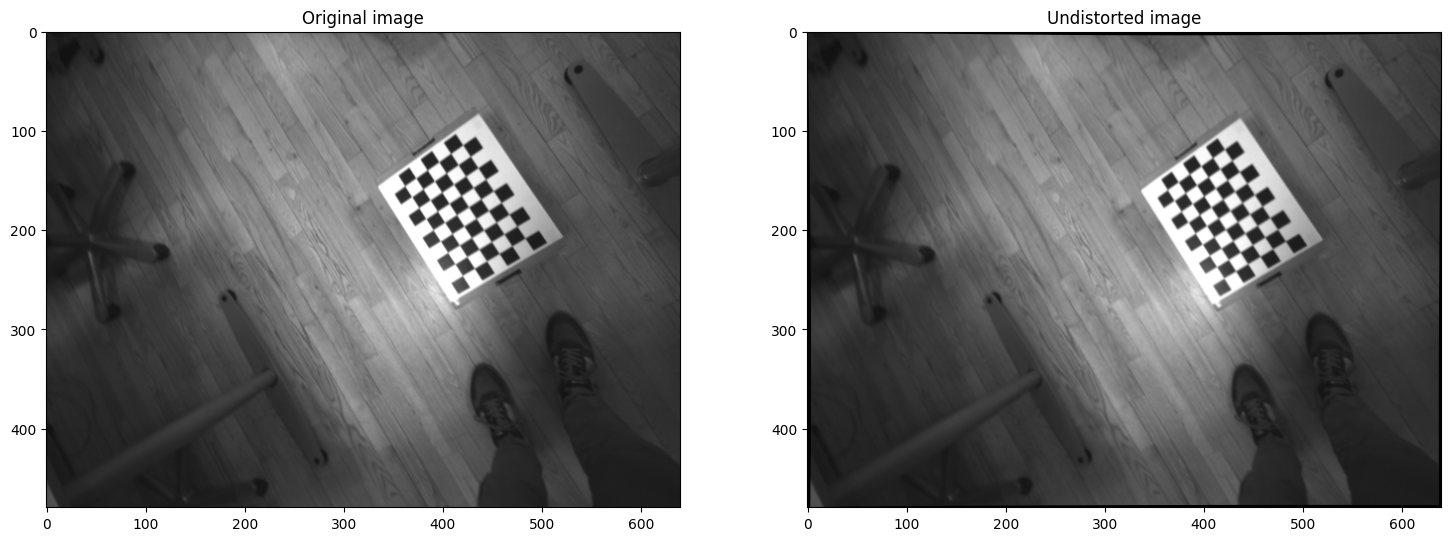

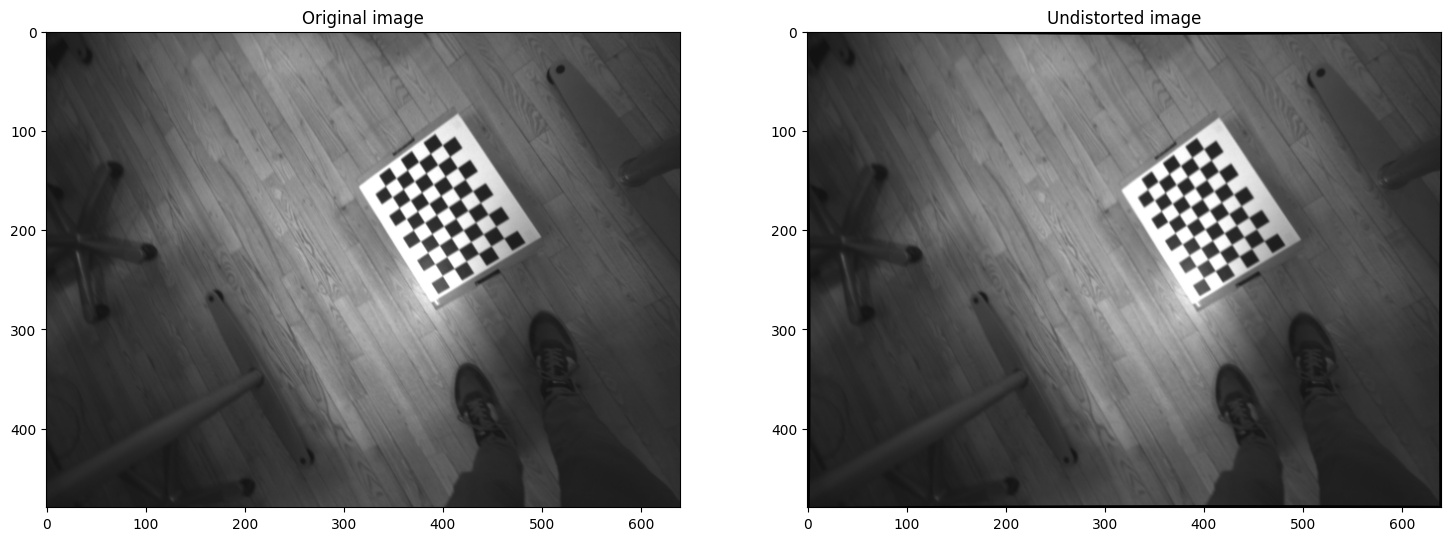

In [23]:
# undistort
dst_left = cv2.undistort(img_left, mtx_left, dist_left, None, newcameramtx_left)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,18))
ax[0].imshow(img_left[...,[2,1,0]])
ax[0].set_title('Original image')
ax[1].imshow(dst_left[...,[2,1,0]])
ax[1].set_title('Undistorted image')

# undistort
dst_right = cv2.undistort(img_right, mtx_right, dist_right, None, newcameramtx_right)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,18))
ax[0].imshow(img_right[...,[2,1,0]])
ax[0].set_title('Original image')
ax[1].imshow(dst_right[...,[2,1,0]])
ax[1].set_title('Undistorted image')

In [42]:
# ============================================================
# 2. SAD FUNCTION - INTERMEDIATE STEP 1
# ============================================================

def SAD(img1, img2):

    img1 = img1.astype(np.int16)
    img2 = img2.astype(np.int16)

    difference = np.abs(img1 - img2)

    return np.sum(difference)


# ============================================================
# 3. FIND BEST MATCH IN A HORIZONTAL SPAN
#    Same idea as intermediate step 3
# ============================================================

def find_best_match(template, span):

    template_width = template.shape[1]
    span_width = span.shape[1]

    best_SAD = np.inf
    best_x = 0

    for x in range(span_width - template_width + 1):

        candidate = span[
            :,
            x:x + template_width
        ]

        score = SAD(template, candidate)

        if score < best_SAD:

            best_SAD = score
            best_x = x

    return best_x, best_SAD


# ============================================================
# 4. FULL STEREO BLOCK MATCHING
# ============================================================

def stereo_block_matching(left, right, block_size=7, max_disparity=64):

    height, width = left.shape

    half = block_size // 2

    # Same size as the original image
    disparity = np.zeros(
        (height, width),
        dtype=np.float32
    )


    # --------------------------------------------------------
    # Move vertically through the image
    # --------------------------------------------------------

    for y in range(half, height - half):


        # ----------------------------------------------------
        # Move horizontally through the image
        # ----------------------------------------------------

        for x in range(half, width - half):


            # ------------------------------------------------
            # Extract 7x7 template from LEFT image
            # ------------------------------------------------

            template = left[
                y-half:y+half+1,
                x-half:x+half+1
            ]


            # ------------------------------------------------
            # Define horizontal search range in RIGHT image
            # ------------------------------------------------

            search_left = max(
                half,
                x - max_disparity
            )

            search_right = x + half + 1


            span = right[
                y-half:y+half+1,
                search_left-half:search_right
            ]


            # ------------------------------------------------
            # Find best match using our previous function
            # ------------------------------------------------

            best_position, best_score = find_best_match(
                template,
                span
            )


            # best_position is relative to the span
            # Convert it back to x coordinate in right image

            x_right = search_left + best_position


            # ------------------------------------------------
            # Calculate disparity
            # ------------------------------------------------

            d = x - x_right

            disparity[y, x] = d


    return disparity


# ============================================================
# 5. RUN OUR IMPLEMENTATION
# ============================================================

dst_left_gray = cv2.cvtColor(dst_left, cv2.COLOR_BGR2GRAY)
dst_right_gray = cv2.cvtColor(dst_right, cv2.COLOR_BGR2GRAY)

disparity = stereo_block_matching(
    dst_left_gray,
    dst_right_gray,
    block_size=7,
    max_disparity=64
)

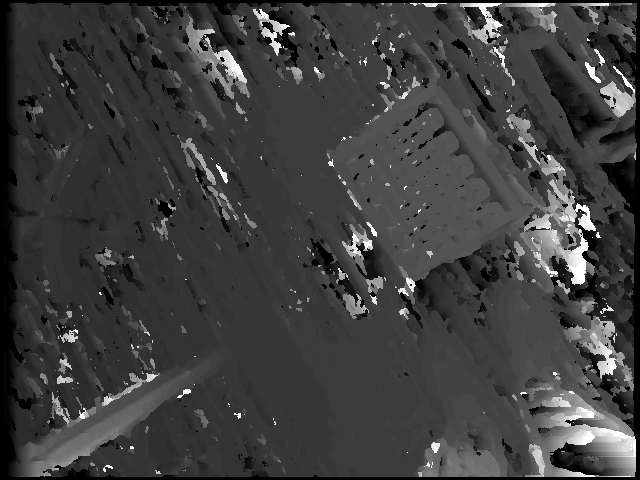

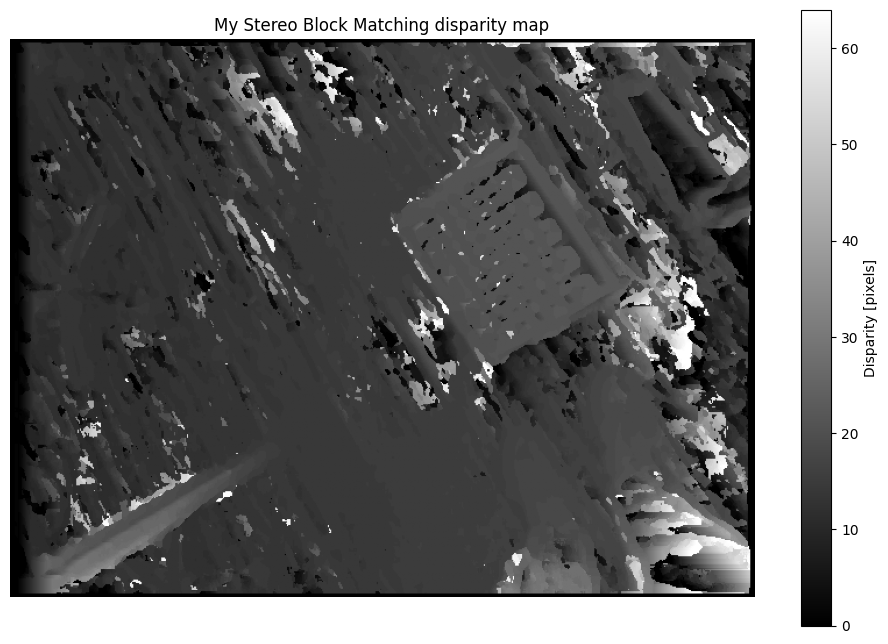

In [43]:
disp_normalized = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
display(Image.fromarray(disp_normalized))

# ============================================================
# 6. DISPLAY RESULT
# ============================================================

plt.figure(figsize=(12, 8))

plt.imshow(disparity, cmap="gray")

plt.title("My Stereo Block Matching disparity map")
plt.colorbar(label="Disparity [pixels]")
plt.axis("off")

plt.show()

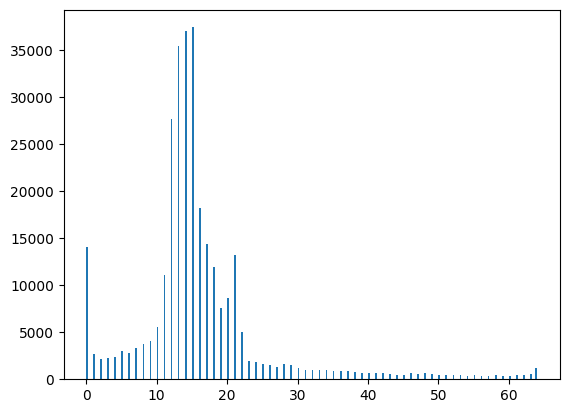

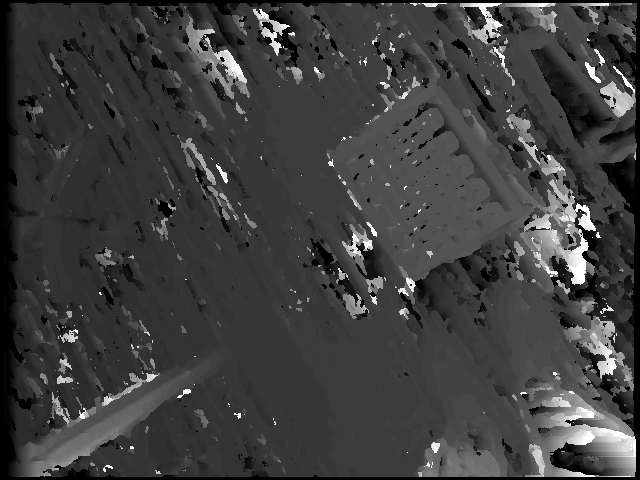

In [48]:
plt.hist(disparity.ravel(), bins=256, range=[0, disparity.max()])
plt.show()

min_clip = np.percentile(disparity, 0)
max_clip = np.percentile(disparity, 100)

disparity_clipped = np.clip(disparity, min_clip, max_clip)
disp_normalized = cv2.normalize(disparity_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

display(Image.fromarray(disp_normalized))


Text(0.5, 1.0, 'Undistorted image')

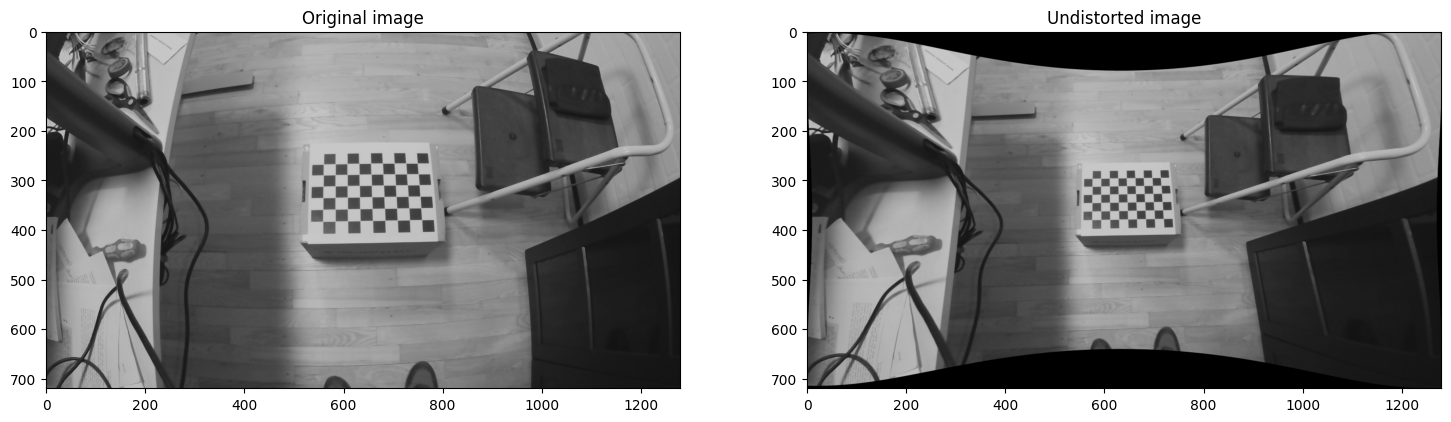

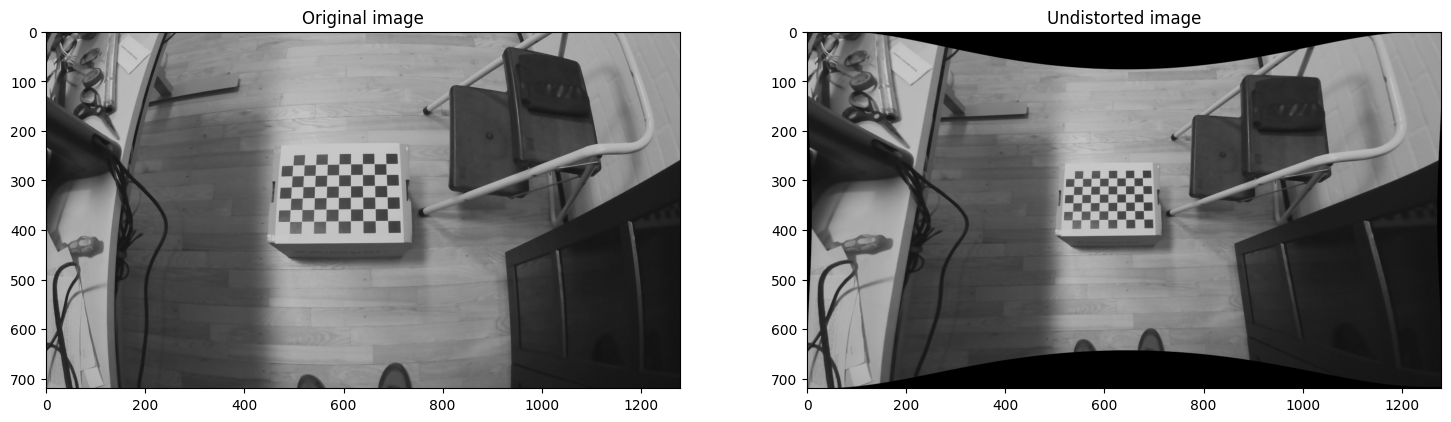

In [51]:

#Implement the number of vertical and horizontal corners

nb_vertical = 9
nb_horizontal = 6


# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((nb_horizontal*nb_vertical,3), np.float32)
objp[:,:2] = np.mgrid[0:nb_vertical,0:nb_horizontal].T.reshape(-1,2)

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints_left= [] # 2d points in image plane.
imgpoints_right=[] #2d points in image plane


images_right = sorted(glob.glob('eyeimages/right-*.png'))
images_left=sorted(glob.glob('eyeimages/left-*.png'))


assert images_right and images_left

criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

for fname_left,fname_right in zip(images_left,images_right):
    img_left = cv2.imread(fname_left)
    gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)

    img_right=cv2.imread(fname_right)
    gray_right=cv2.cvtColor(img_right,cv2.COLOR_BGR2GRAY)

    
    #Implement findChessboardCorners here
    ret_left, corners_left = cv2.findChessboardCorners(gray_left,(nb_vertical, nb_horizontal))
    ret_right,corners_right=cv2.findChessboardCorners(gray_right,(nb_vertical,nb_horizontal))


    # If found, add object points, image points (after refining them)
    if ret_left == True and ret_right==True:

        corners_left = cv2.cornerSubPix(
        gray_left, corners_left, (11, 11), (-1, -1), criteria
        )
        corners_right = cv2.cornerSubPix(
        gray_right, corners_right, (11, 11), (-1, -1), criteria
        )

        objpoints.append(objp)

        imgpoints_left.append(corners_left)
        imgpoints_right.append(corners_right)

        # Draw and display the corners
        img_left = cv2.drawChessboardCorners(img_left, (nb_vertical,nb_horizontal), corners_left,ret_left)
        cv2.imshow('img',img_left)
        cv2.waitKey(100)

        img_right=cv2.drawChessboardCorners(img_right,(nb_vertical,nb_horizontal), corners_right, ret_right)
        cv2.imshow('img',img_right)
        cv2.waitKey(100)

cv2.destroyAllWindows()

ret_left, mtx_left, dist_left, rvecs_left, tvecs_left = cv2.calibrateCamera(objpoints, imgpoints_left, gray_left.shape[::-1], None, None, flags=cv2.CALIB_FIX_K3)
img_left = cv2.imread('eyeimages/left-0000.png')
h,  w = img_left.shape[:2]
newcameramtx_left, roi_left = cv2.getOptimalNewCameraMatrix(mtx_left,dist_left,(w,h),1,(w,h))

ret_right, mtx_right, dist_right,rvecs_right,tvecs_right=cv2.calibrateCamera(objpoints, imgpoints_right,gray_right.shape[::-1],None, None, flags=cv2.CALIB_FIX_K3)
img_right=cv2.imread('eyeimages/right-0000.png')
h, w=img_right.shape[:2]
newcameramtx_right, roi_right=cv2.getOptimalNewCameraMatrix(mtx_right,dist_right,(w,h),1,(w,h))

# undistort
dst_left = cv2.undistort(img_left, mtx_left, dist_left, None, newcameramtx_left)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,18))
ax[0].imshow(img_left[...,[2,1,0]])
ax[0].set_title('Original image')
ax[1].imshow(dst_left[...,[2,1,0]])
ax[1].set_title('Undistorted image')

# undistort
dst_right = cv2.undistort(img_right, mtx_right, dist_right, None, newcameramtx_right)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,18))
ax[0].imshow(img_right[...,[2,1,0]])
ax[0].set_title('Original image')
ax[1].imshow(dst_right[...,[2,1,0]])
ax[1].set_title('Undistorted image')

In [58]:
# ============================================================
# 5. RUN OUR IMPLEMENTATION
# ============================================================

dst_left_gray = cv2.cvtColor(dst_left, cv2.COLOR_BGR2GRAY)
dst_right_gray = cv2.cvtColor(dst_right, cv2.COLOR_BGR2GRAY)

disparity = stereo_block_matching(
    dst_left_gray,
    dst_right_gray,
    block_size=7,
    max_disparity=64
)

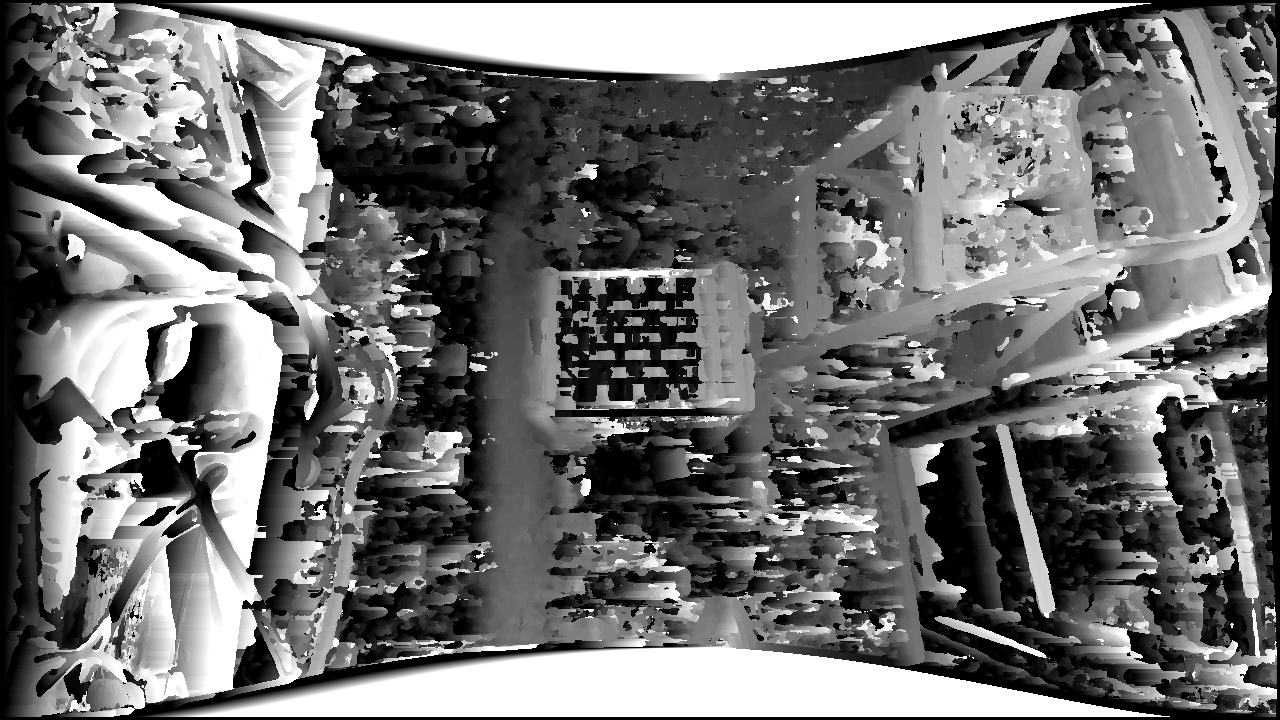

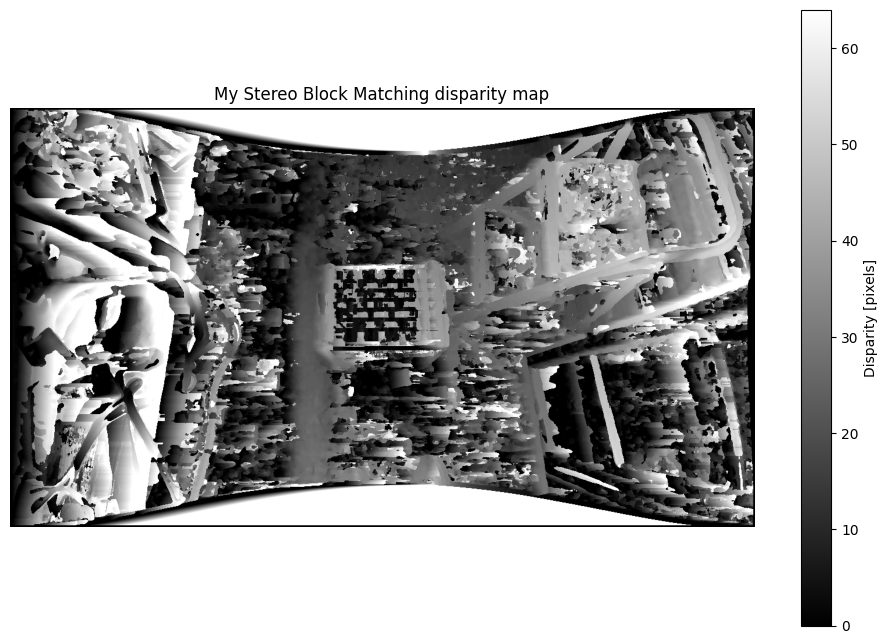

In [59]:
disp_normalized = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
display(Image.fromarray(disp_normalized))

# ============================================================
# 6. DISPLAY RESULT
# ============================================================

plt.figure(figsize=(12, 8))

plt.imshow(disparity, cmap="gray")

plt.title("My Stereo Block Matching disparity map")
plt.colorbar(label="Disparity [pixels]")
plt.axis("off")

plt.show()

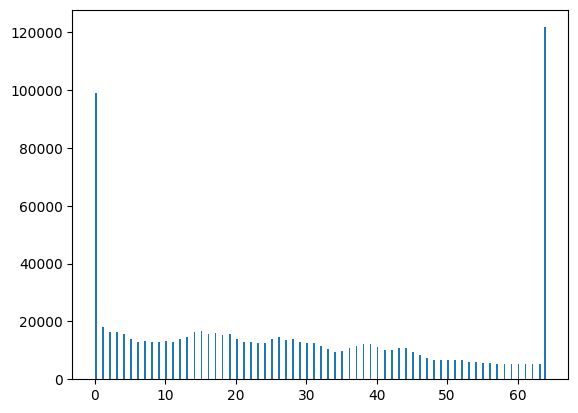

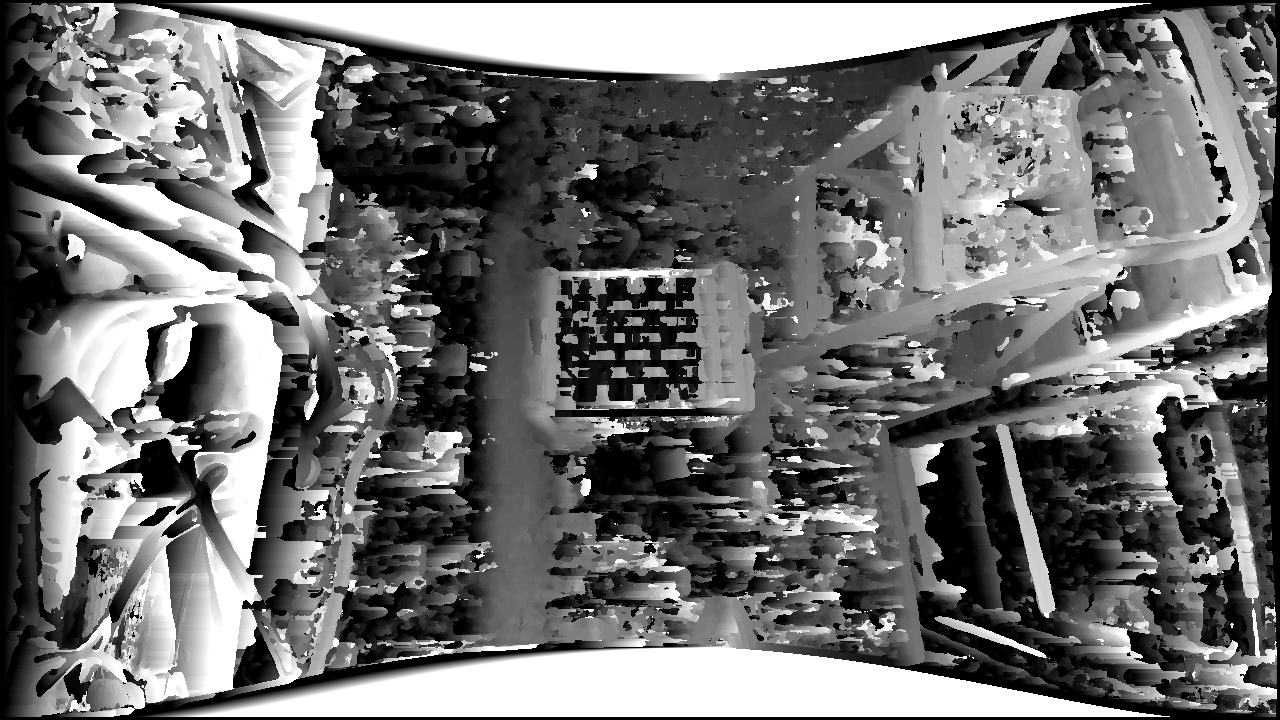

In [60]:
plt.hist(disparity.ravel(), bins=256, range=[0, disparity.max()])
plt.show()

min_clip = np.percentile(disparity, 0)
max_clip = np.percentile(disparity, 100)

disparity_clipped = np.clip(disparity, min_clip, max_clip)
disp_normalized = cv2.normalize(disparity_clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

display(Image.fromarray(disp_normalized))
